# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

In [6]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Instantiate a rendering and a non-rendering environment.
env_render = gym.make('CartPole-v1', render_mode='human')
env = gym.make('CartPole-v1')

seed = 2112

env.reset(seed=seed)
torch.manual_seed(seed)

In [7]:
print(f'Observation Space: {env.observation_space}')
print(f'Action Space: {env.action_space}')

observation, info = env.reset()
print(f'Observation: {observation}')
print(f"observation type: {type(observation)}")

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)
Observation: [-0.04166599 -0.01788354 -0.00474543  0.01090227]
observation type: <class 'numpy.ndarray'>


In [8]:
obs, reward, terminated, truncated, _ = env.step(env.action_space.sample())

print(f'Observation: {obs}')
print(f'Reward: {reward}')
print(f'reward type: {type(reward)}')
print(f'Terminated: {terminated}')
print(f'Terminated type: {type(terminated)}')
print(f'Truncated: {truncated}')

Observation: [-0.04202366 -0.21293712 -0.00452739  0.30208418]
Reward: 1.0
reward type: <class 'float'>
Terminated: False
Terminated type: <class 'bool'>
Truncated: False


Come possiamo osservare l'environment ha uno spazio in cui ci si può muovere ed è rappresentato dai limiti presenti nello spazio delle osservaizoni, in questo caso sono 4 variabili libere poiché il cartpole ha 2 gradi di libertà, la posizione sull'asse orizzontale e l'inclinazione dell'asta.
Le variabili sono quindi:
- **Velocità angolare** dell'asta.
- **Angolo** dell'asta.
- **Posizione** del carrello.
- **Velocità** del carrello.

Le azioni che possiamo scegliere, ovvero la dimensione dello spazio delle azioni, sono 2 poiché il carrello può spostarsi a destra o sinistra a seconda della mossa necessaria a contro-bilanciare la caduta dell'asta; `env.reset(seed = seed)` restituisce un'osservazione della posizione inizializzata casualmente sulla base del seed.

Il metodo env.step(action) esegue l'azione scelta nell'ambiente (che nel tuo caso di test viene campionata casualmente) e restituisce una tupla contenente quattro informazioni fondamentali:
-	**Observation**: Il nuovo stato del sistema generato a seguito dell'azione (nel CartPole, il vettore con le 4 posizioni e velocità).
-	**Reward**
-	**Terminated**: Un flag booleano che indica se l'episodio è finito perché l'agente ha raggiunto un obiettivo o ha fallito.
-	**Truncated**: Un flag booleano che indica se l'episodio è stato interrotto per motivi esterni alle regole del gioco.

**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

In [10]:
class PolicyNet(nn.Module):
    def __init__(self, env):
        super().__init__()
        self.fc1 = nn.Linear(env.observation_space.shape[0], 128)
        self.fc2 = nn.Linear(128, env.action_space.n)
        
    def forward(self, s):
        s = F.relu(self.fc1(s))
        s = F.softmax(self.fc2(s), dim=-1)
        return s

In [11]:
def loss(log_probs, returns):
    return (-log_probs * returns).mean()

Running reward: 1.1497842788696289
Running reward: 88.70264878082557
Running reward: 97.97101272853854
Running reward: 88.37286026222495
Running reward: 97.90726891933801
Running reward: 87.48238385097217
Running reward: 98.4336523771478
Running reward: 89.406901245159
Running reward: 98.55938823747957
Running reward: 99.33830981969528


Text(0, 0.5, 'Reward')

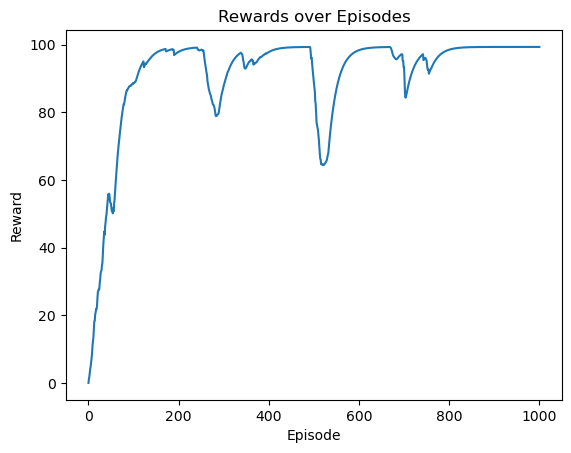

In [12]:
from Agents import ReinforceAgent

policy = PolicyNet(env)
agent = ReinforceAgent(policy=policy, optimizer=optim.Adam(policy.parameters(), lr=0.01), env=env, gamma=0.99, loss=loss)

rewards, _, _= agent.reinforce(num_episodes=1000, checkpoint=True, N = 0, M = 0, standardize = True)
plt.plot(rewards)
plt.title('Rewards over Episodes')
plt.xlabel('Episode')
plt.ylabel('Reward')

**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

In [ ]:
def plot_rewards(running_rewards, M_mean_reward, M_mean_length):
     print("Check lunghezze:", len(M_mean_reward) == len(M_mean_length))

     plt.figure(figsize=(16, 5))

     plt.subplot(1, 3, 1) # (1 riga, 3 colonne, posizione 1)
     plt.plot(running_rewards, color='green')
     plt.title('Running Reward (Training)')
     plt.xlabel('Episodio')
     plt.ylabel('Score (EMA)')
     plt.grid(True, linestyle=':', alpha=0.6)

     plt.subplot(1, 3, 2) # (1 riga, 3 colonne, posizione 2)
     plt.plot(M_mean_reward, color='blue')
     plt.title('Mean Reward (Evaluation)')
     plt.xlabel('Step di Valutazione (ogni 50 ep.)')
     plt.ylabel('Reward Medio')
     plt.grid(True, linestyle=':', alpha=0.6)

     plt.subplot(1, 3, 3) # (1 riga, 3 colonne, posizione 3)
     plt.plot(M_mean_length, color='orange')
     plt.title('Mean Length (Evaluation)')
     plt.xlabel('Step di Valutazione (ogni 50 ep.)')
     plt.ylabel('Lunghezza Media Episodio')
     plt.grid(True, linestyle=':', alpha=0.6)

     plt.tight_layout()
     plt.show()

Mean reward: 19.0, Mean length: 19.0
Running reward: 0.8274312019348145
Mean reward: 57.3, Mean length: 57.3
Mean reward: 151.95, Mean length: 151.95
Running reward: 70.08321196091983
Mean reward: 500.0, Mean length: 500.0
Mean reward: 415.9, Mean length: 415.9
Running reward: 97.01225392156718
Mean reward: 478.7, Mean length: 478.7
Mean reward: 290.2, Mean length: 290.2
Running reward: 81.08896273961744
Mean reward: 500.0, Mean length: 500.0
Mean reward: 160.0, Mean length: 160.0
Running reward: 96.38573264217115
Mean reward: 203.05, Mean length: 203.05
Mean reward: 54.0, Mean length: 54.0
Running reward: 43.86442566535048
Mean reward: 66.6, Mean length: 66.6
Mean reward: 42.1, Mean length: 42.1
Running reward: 43.63917022806725
Mean reward: 270.25, Mean length: 270.25
Mean reward: 147.5, Mean length: 147.5
Running reward: 76.46483117229342
Mean reward: 475.45, Mean length: 475.45
Mean reward: 381.0, Mean length: 381.0
Running reward: 98.63750588990352
Mean reward: 500.0, Mean length:

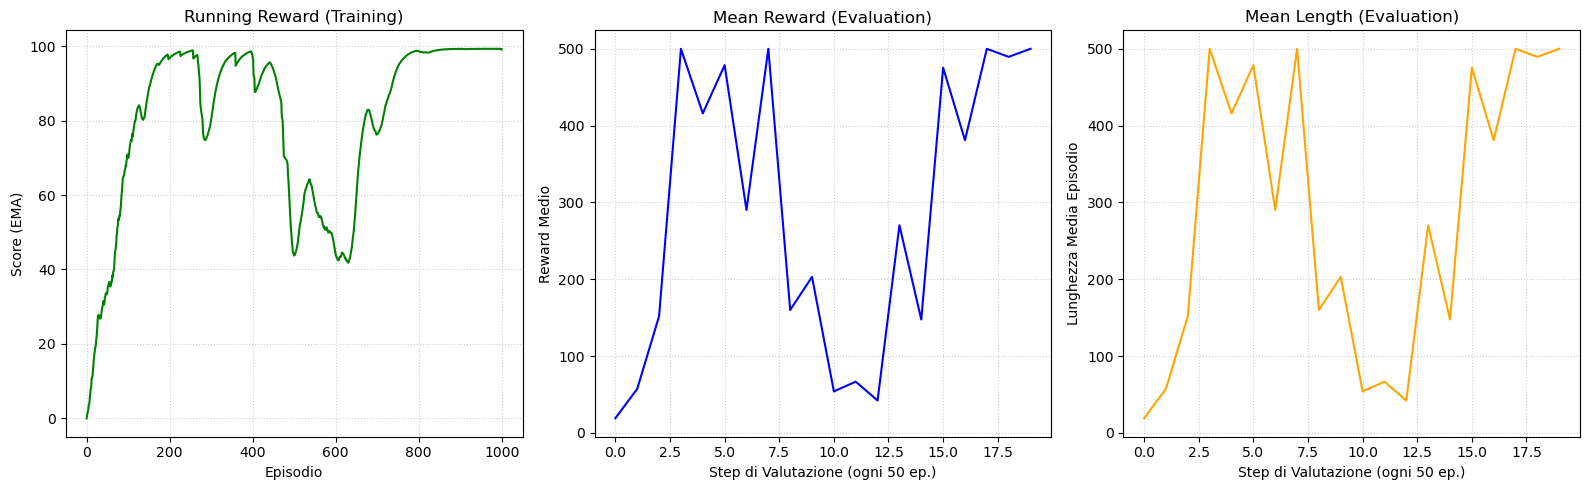

In [14]:
policy = PolicyNet(env)
agent = ReinforceAgent(policy=policy, optimizer=optim.Adam(policy.parameters(), lr=0.01), env=env, gamma=0.99, loss=loss)
running_rewards, M_mean_reward, M_mean_length = agent.reinforce(num_episodes=1000, checkpoint=True, N=50, M=20, standardize=True)
plot_rewards(running_rewards, M_mean_reward, M_mean_length)

Dall'analisi congiunta delle tre curve di performance emergono diverse considerazioni fondamentali sulle dinamiche di apprendimento dell'agente su 1000 episodi complessivi:
1. **Instabilità della Policy e Variabilità dei Gradienti**
     Come si evince chiaramente dall'andamento oscillatorio di tutte e tre le curve, l'agente mostra una marcata difficoltà nel consolidare una policy stabile. Sebbene la rete riesca a raggiungere il picco massimo di performance già nelle prime fasi della curva, si possono osservare crolli drastici e repentini.
     Questo andamento rappresenta il comportamento tipico dell'algoritmo REINFORCE. Poiché l'aggiornamento dei pesi si basa sui ritorni di interi episodi, l'algoritmo soffre di un'elevata varianza nei gradienti.
2. **Coerenza e Correlazione tra le Metriche**
     Nonostante il Running Reward sia una metrica rumorosa e meno indicativa rispetto alle medie calcolate, si osserva una perfetta correlazione temporale tra le curve di valutazione.
     Poiché la policy viene valutata in un ambiente separato ogni $N = 50$ episodi, i minimi locali registrati nei grafici di test (ad esempio lo step di valutazione numero 8 e numero 17) rispecchiano i crolli visibili nel grafico di training (rispettivamente agli episodi 400 e 850).
3. **Simmetria Tra Punteggio e Sopravvivenza**
     I due grafici di valutazione risultano speculari e geometricamente identici. Questa caratteristica è legata alla struttura nativa dell'ambiente `CartPole-v1`, in cui l'agente riceve una ricompensa fissa di $+1$ per ogni istante temporale in cui l'asta rimane in equilibrio. Di conseguenza, la massimizzazione del profitto coincide con il prolungamento della sopravvivenza prima del fallimento.

Nota: Perché il running reward si ferma a 100 e non a 500 come negli altri 2 grafici, la risposta sta nella formula utilizzata per i discounted rewards $$G = r_t + \gamma r_{t+1} + \dots + \gamma^{T-1}r_T = \sum_{i=0}^{T-1}r_t\gamma^t = \frac{1}{1-\gamma}=100$$ dove T è la lunghezza dell'episodio

-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

Mean reward: 19.5, Mean length: 19.5
Running reward: 0.4780896186828614
Mean reward: 20.3, Mean length: 20.3
Mean reward: 49.9, Mean length: 49.9
Running reward: 23.27037224621639
Mean reward: 60.7, Mean length: 60.7
Mean reward: 33.6, Mean length: 33.6
Running reward: 34.102969167982145
Mean reward: 88.05, Mean length: 88.05
Mean reward: 20.8, Mean length: 20.8
Running reward: 28.675859027257804
Mean reward: 9.5, Mean length: 9.5
Mean reward: 8.85, Mean length: 8.85
Running reward: 9.004929171461042
Mean reward: 9.45, Mean length: 9.45
Mean reward: 9.55, Mean length: 9.55
Running reward: 8.886846016100762
Mean reward: 9.15, Mean length: 9.15
Mean reward: 9.3, Mean length: 9.3
Running reward: 8.968849820409346
Mean reward: 9.35, Mean length: 9.35
Mean reward: 9.6, Mean length: 9.6
Running reward: 9.08459038064659
Mean reward: 9.45, Mean length: 9.45
Mean reward: 9.25, Mean length: 9.25
Running reward: 9.051260242018943
Mean reward: 9.3, Mean length: 9.3
Mean reward: 9.15, Mean length: 

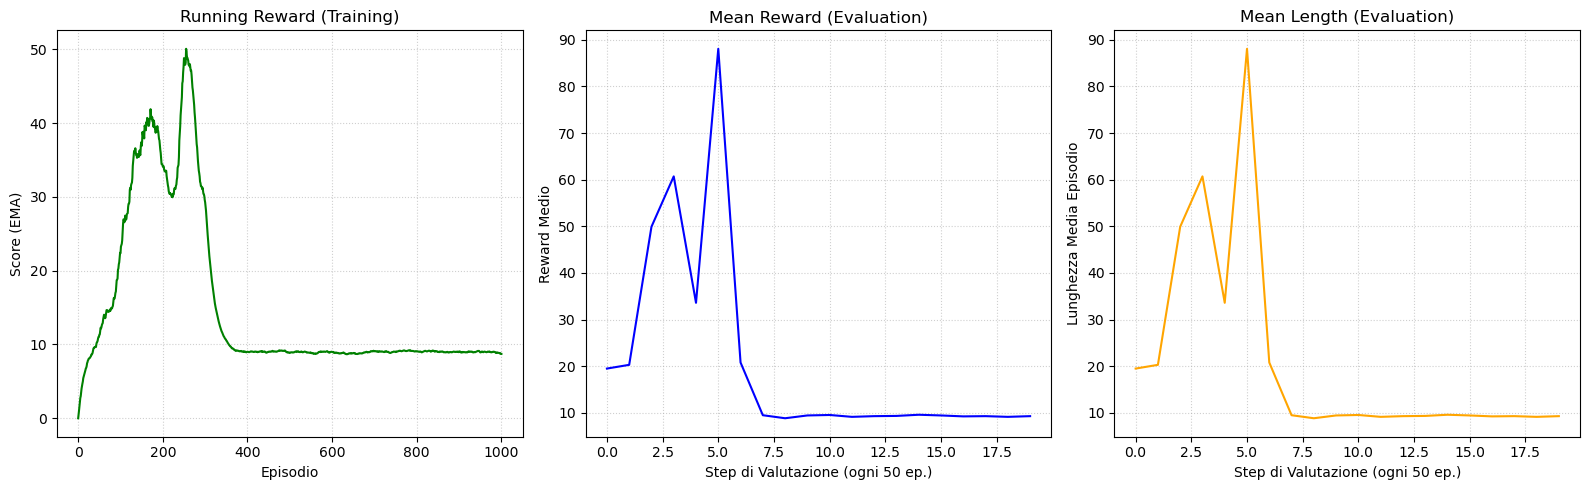

In [15]:
# Your code here. Modify your implementation of `REINFORCE` to optionally use the standardize baseline.
policy = PolicyNet(env)
agent = ReinforceAgent(policy=policy, optimizer=optim.Adam(policy.parameters(), lr=0.01), env=env, gamma=0.99, loss=loss)
running_rewards, M_mean_reward, M_mean_length = agent.reinforce(num_episodes=1000, checkpoint=True, N=50, M=20, standardize=False)
plot_rewards(running_rewards, M_mean_reward, M_mean_length)

La **rimozione della baseline basata sulla media e standardizzazione dei ritorni** evidenzia alcune delle problematiche dell'algoritmo REINFORCE:

1. **Il Fenomeno dell'Over-Confidence e la Saturazione del Softmax**
     Nell'ambiente `CartPole-v1`, il sistema restituisce una ricompensa costantemente positiva ($+1$) per ogni istante di sopravvivenza. Di conseguenza, in assenza di una baseline di confronto, l'algoritmo si trova sempre con valori di $G_t > 0$.
     Questo spinge la rete ad aumentare indistintamente la probabilità di qualsiasi azione eseguita durante l'episodio, comprese le azioni causano la caduta del palo. Questo porta le probabilità in uscita dalla rete che modella la policy a saturare istantaneamente verso valori estremi.
2. **Scomparsa del Gradiente ed Estinzione dell'Esplorazione**
     Una volta che la policy diventa deterministica a causa dell'over-confidence, l'agente cessa completamente di esplorare l'ambiente, continuando a selezionare la stessa identica azione .
     Da un punto di vista matematico, quando la probabilità di un'azione si avvicina asintoticamente a $1$, la derivata della funzione Softmax tende a zero. Questo annulla il gradiente della loss, congelando di fatto l'apprendimento della rete. Come evidenziato chiaramente dal grafico piatto a partire dal ventesimo episodio, l'agente rimane intrappolato in un minimo locale, registrando la minima durata possibile dell'episodi.

**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

In [16]:
class CriticNet(nn.Module):
    def __init__(self, env):
        super().__init__()
        self.fc1 = nn.Linear(env.observation_space.shape[0], 128)
        self.fc2 = nn.Linear(128, 1)
        
    def forward(self, s):
        s = F.relu(self.fc1(s))
        s = self.fc2(s)
        return s.view(-1) #force the output to be a 1D tensor, as we want a single value for each state

In [17]:
from Agents import ReinforceAgentWithBaseline

policy = PolicyNet(env)
critic = CriticNet(env)

policy_optimizer = optim.Adam(policy.parameters(), lr=5e-4)
critic_optimizer = optim.Adam(critic.parameters(), lr=1e-3)

agent = ReinforceAgentWithBaseline(policy=policy, baseline=critic, opt=policy_optimizer, critic_opt=critic_optimizer, env=env, gamma=0.99, loss=loss)

Mean reward: 22.05, Mean length: 22.05
Running reward: 0.8691568374633789
Mean reward: 20.2, Mean length: 20.2
Mean reward: 19.25, Mean length: 19.25
Running reward: 17.51868299379079
Mean reward: 26.85, Mean length: 26.85
Mean reward: 25.55, Mean length: 25.55
Running reward: 24.73702200086874
Mean reward: 42.95, Mean length: 42.95
Mean reward: 48.8, Mean length: 48.8
Running reward: 36.84054128717891
Mean reward: 67.35, Mean length: 67.35
Mean reward: 82.5, Mean length: 82.5
Running reward: 45.658641057404935
Mean reward: 117.9, Mean length: 117.9
Mean reward: 139.2, Mean length: 139.2
Running reward: 70.49244102300781
Mean reward: 213.4, Mean length: 213.4
Mean reward: 225.2, Mean length: 225.2
Running reward: 85.36904475226913
Mean reward: 214.85, Mean length: 214.85
Mean reward: 255.25, Mean length: 255.25
Running reward: 88.95055100054107
Mean reward: 381.0, Mean length: 381.0
Mean reward: 337.65, Mean length: 337.65
Running reward: 93.14151675564925
Mean reward: 293.95, Mean len

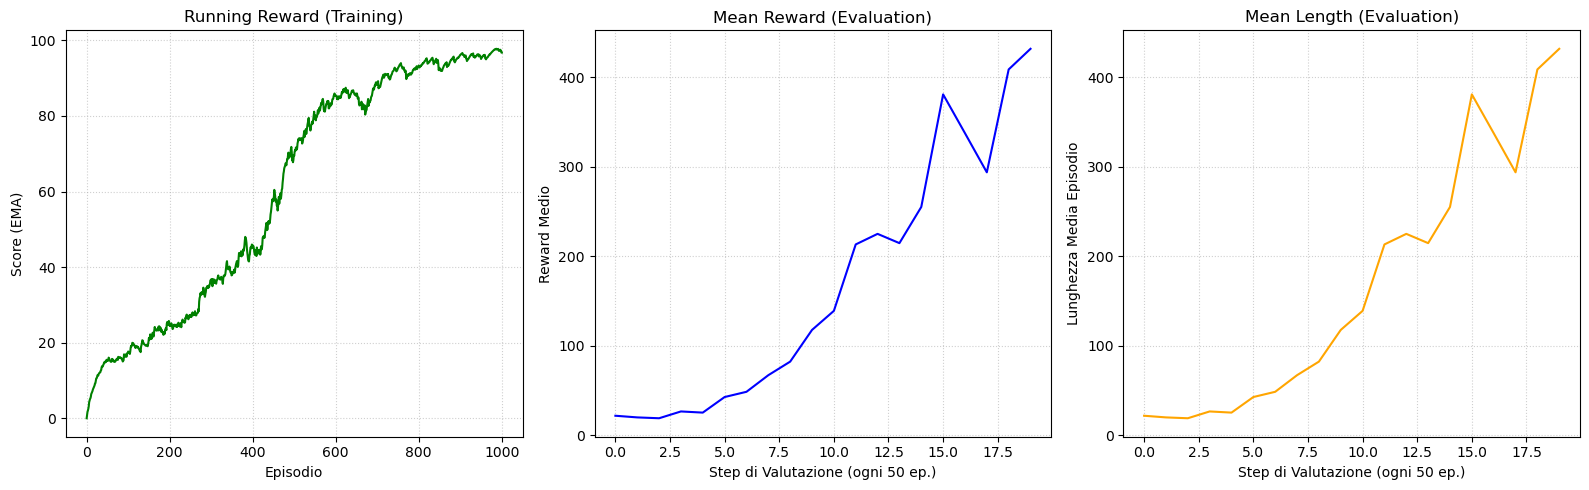

Text(0, 0.5, 'Value Loss')

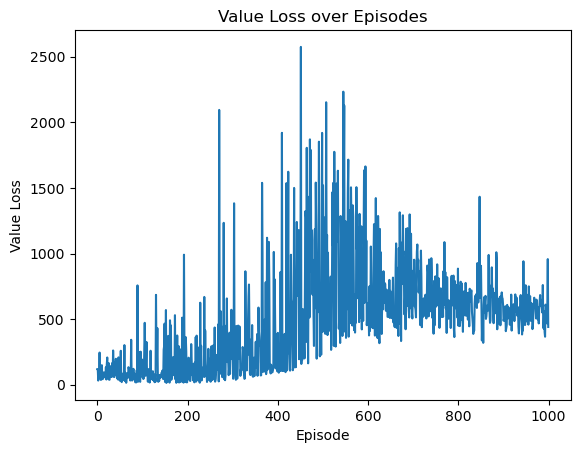

In [18]:
results = agent.reinforce(num_episodes=1000, checkpoint=True, N=50, M=20)
running_rewards, M_mean_reward, M_mean_length = results
plot_rewards(running_rewards, M_mean_reward, M_mean_length)
plt.plot(results.loss_values)
plt.title('Value Loss over Episodes')
plt.xlabel('Episode')
plt.ylabel('Value Loss')

Come possiamo vedere, **l'introduzione della baseline ha stabilizzato l'apprendimento** in modo evidente: la varianza tra i reward dei vari episodi è nettamente inferiore, e la policy appresa risulta più solida, senza i crolli improvvisi osservati in precedenza.
Si tratta di un risultato atteso, poiché la seconda rete, addestrata a stimare **la state value function**, fornisce una baseline rispetto a cui misurare quanto il reward ottenuto si discosti dal valore atteso in quello stato.
Questo vantaggio riduce la varianza dello stimatore del gradiente senza introdurne il bias, dato che la baseline non dipende dall'azione scelta ma solo dallo stato.

Ho incluso anche l'andamento della loss per curiosità, ma va precisato che in questo contesto non è una metrica informativa sulle prestazioni del sistema. A differenza del supervised learning, dove la loss rappresenta un vero costo da minimizzare, qui _è un termine costruito unicamente per produrre il gradiente corretto_ per l'aggiornamento della policy.
Il suo valore e il suo andamento nel tempo non sono indicativi della qualità della policy appresa.


-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import GrayscaleObservation, ResizeObservation, FrameStackObservation

car_race_env = gym.make_vec("CarRacing-v3", continuous=False, render_mode='human')  # azioni discrete
car_race_env = GrayscaleObservation(car_race_env, keep_dim=False)
car_race_env = ResizeObservation(car_race_env, (84, 84))
car_race_env = FrameStackObservation(car_race_env, stack_size=4)

objc[1951]: Class SDLApplication is implemented in both /Users/lapotinacci/miniconda3/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x107ef0a68) and /Users/lapotinacci/miniconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x15ed68890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[1951]: Class SDLAppDelegate is implemented in both /Users/lapotinacci/miniconda3/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x107ef0ab8) and /Users/lapotinacci/miniconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x15ed688e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[1951]: Class SDLTranslatorResponder is implemented in both /Users/lapotinacci/miniconda3/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x107ef0b30) and /Users/lapotinacci/miniconda3/lib/python3.13/s

In [5]:
print(f'Observation Space: {car_race_env.observation_space.shape}')
print(f'car_race_env type: {type(car_race_env.observation_space)}')
print(f'Action Space: {car_race_env.action_space}')

Observation Space: (4, 84, 84)
car_race_env type: <class 'gymnasium.spaces.box.Box'>
Action Space: Discrete(5)


In [11]:
policy_net = DCQN(car_race_env.observation_space.shape, car_race_env.action_space.n)  # type: ignore     
target_net = DCQN(car_race_env.observation_space.shape, car_race_env.action_space.n)  # type: ignore

optimizer = optim.Adam(policy_net.parameters(), lr=5e-4)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
  
memory_size = 100000
memory = deque(maxlen=memory_size)
agent = DeepQLearningAgent(
    policy_net=policy_net, target_net=target_net, optimizer=optimizer,
    env=car_race_env, memory=memory, loss_fn=huber_loss,
    batch_size=128, gamma=0.99, tau=0.005, double=True, device=device
)

In [ ]:
rewards, lengths, losses = agent.DeepQLearning(  
    episodes=5000,
    epsilon=1.0, epsilon_min=0.02, epsilon_decay=0.002,     
    max_steps=1000,
    start_training=10000,     
    N=25, M=20,              
)

Training:   0%|          | 0/5000 [00:40<?, ?it/s]


KeyboardInterrupt: 